In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Calculating acceleration and graphing

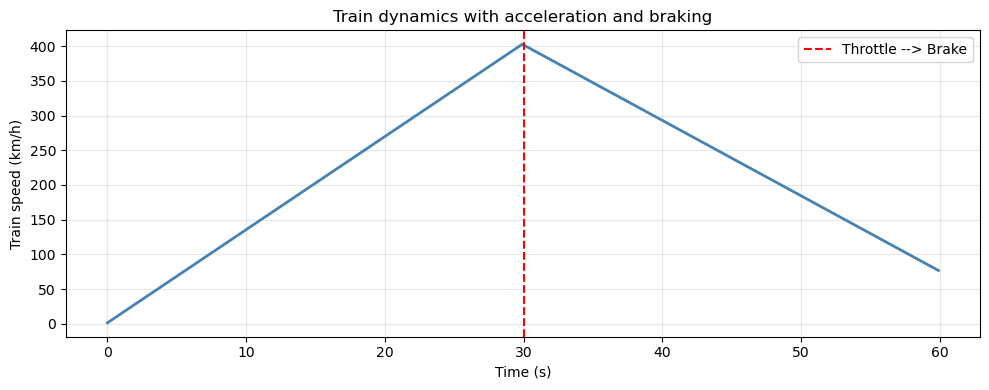

In [2]:
MASS = 4e4
MAX_TRACTION = 15e4
MAX_BRAKE = 12e4
ROLLING_RES = 2e-3
# seconds per timestep
DT = 0.1

def train_acceleration(v, throttle, brake, gradient_deg=0):

    #the component of the gravitational force which is parallel to the gradient
    f_slope = -MASS * 9.81 * np.sin(np.radians(gradient_deg))
    
    #force that comes from the brakes
    f_brake = -brake * MAX_BRAKE

    #the resistive force that comes from the tires of the train.
    f_rolling_res = -ROLLING_RES * MASS * 9.81

    f_traction = MAX_TRACTION * throttle

    f_net = f_slope + f_brake + f_rolling_res + f_traction

    #F_net = mass * acceleration
    return f_net / MASS

#60 seconds of simulation
steps = 600
#velocity of the train, initially zero
velocity = 0.0
#the speeds to be plotted
speeds = []

#divides the steps into equal parts, from 0 to 59.9, 0.0,0.1....
times = np.arange(steps) * DT

for i, t in enumerate(times):

    #train accelerates in the first 30 seconds then starts to use the brakes
    throttle = 1.0 if t < 30 else 0.0
    brake = 0.0 if t < 30 else 1.0

    a = train_acceleration(velocity, throttle, brake)
    
    #calculating the velocity from the formula: v_final = v_initial + a*t
    velocity = max(0.0, velocity + a * DT)

    # m/s -> km/h
    speeds.append(velocity * 3.6)

#size of the plot
plt.figure(figsize=(10,4))

#the x,y variables;line color and width
plt.plot(times, speeds, color="steelblue", linewidth=2)

#drawing the point the train starts decelearting
plt.axvline(30, color="red", linestyle="--", label="Throttle --> Brake")
plt.xlabel("Time (s)")
plt.ylabel("Train speed (km/h)")
plt.title("Train dynamics with acceleration and braking")

#showing the gridlines
plt.grid(True,alpha=0.3)

#
plt.legend()
plt.tight_layout()
plt.show()

### Graphing with different gradients

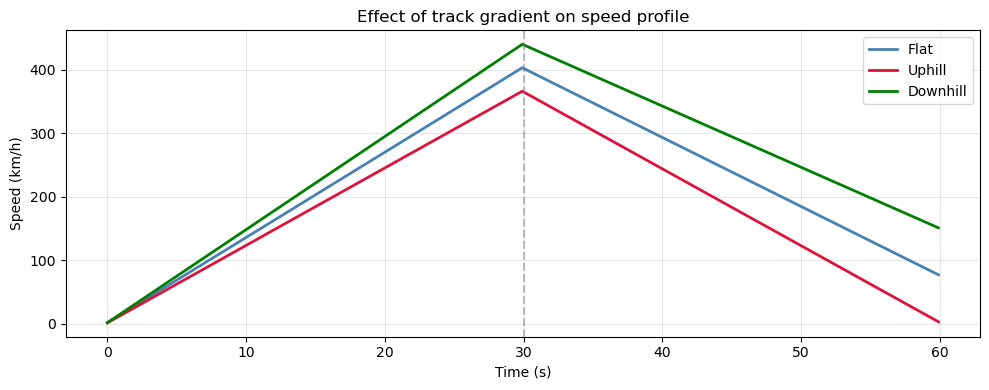

In [3]:
fig, ax = plt.subplots(figsize=(10,4))

for grad, label, color in [(0, "Flat", "steelblue"),
                           (2,"Uphill", "crimson"),
                           (-2,"Downhill","green")]:

    velocity = 0.0
    speeds = []

    for t in times:

        throttle = 1.0 if t < 30 else 0.0
        brake = 0.0 if t < 30 else 1.0

        a = train_acceleration(velocity, throttle, brake, grad)
        velocity = max(0.0, velocity + a * DT)
        speeds.append(velocity * 3.6)

    ax.plot(times, speeds, label=label, color=color, linewidth=2)

ax.axvline(30, color="gray", linestyle='--', alpha=0.5)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Speed (km/h)")
ax.set_title("Effect of track gradient on speed profile")
ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()
plt.show()
    


### Graphing position and velocity graphs

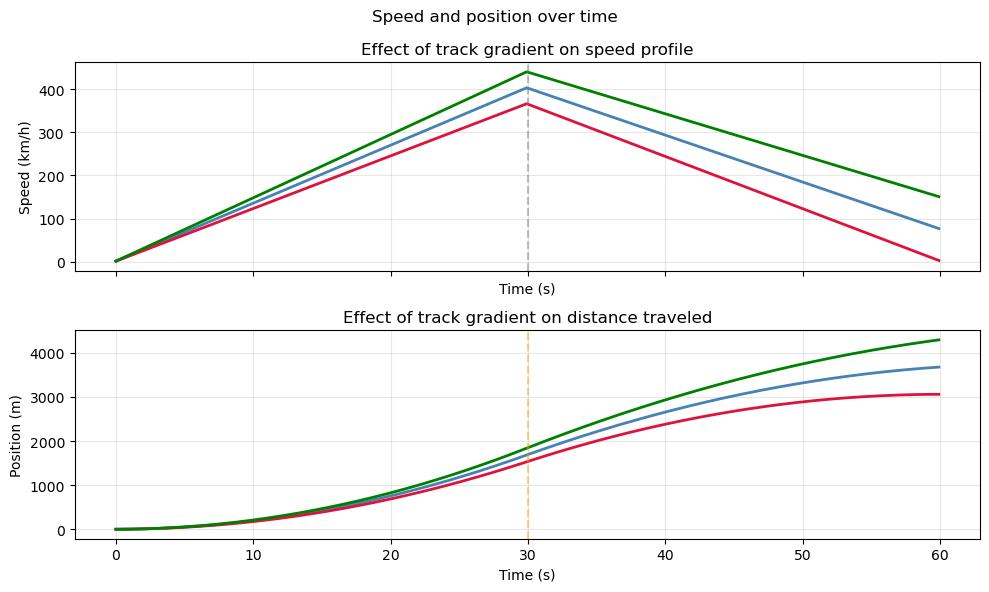

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

for grad, label, color in [(0, "Flat", "steelblue"),
                           (2,"Uphill", "crimson"),
                           (-2,"Downhill","green")]:

    velocity = 0.0
    position = 0.0
    
    speeds, positions = [], []
    
    for t in times:
    
        throttle = 1.0 if t < 30 else 0.0
        brake = 0.0 if t < 30 else 1.0
    
        a = train_acceleration(velocity, throttle, brake, grad)
        
        velocity = max(0.0, velocity + a * DT)
        position = position + velocity * DT
        
        speeds.append(velocity * 3.6)
        positions.append(position)

    ax1.plot(times, speeds, label=label, color=color, linewidth=2)
    ax2.plot(times, positions, label=label, color=color, linewidth=2)

ax1.axvline(30, color="gray", linestyle='--', alpha=0.5)
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Speed (km/h)")
ax1.set_title("Effect of track gradient on speed profile")
ax1.grid(True, alpha=0.3)

ax2.axvline(30, color="orange", linestyle='--', alpha=0.5)
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Position (m)")
ax2.set_title("Effect of track gradient on distance traveled")
ax2.grid(True, alpha=0.3)

plt.suptitle("Speed and position over time")
plt.tight_layout()
plt.show()




### PID Controller Notes

If we use ON/OFF control, the room temperature for example will fluctuate around the target value, which is not ideal for industries.

PID : Proportional, Integral, Derivative

Error = Setpoint - process_variable

Proportional: deals with the instantaneous error. (K_p*e(t))


Integral: the error that accumulates over time. (integral of K_i*dt between zero to t). this will prevent the offset that might appear in a P controller


Derivative: analyzes the rate of change of the error and reacts accordingly, dampening rapid changes

Output error: proportional_error + integral_error + derivative_error

Based on this error, the train will react as a throttle or break>

In [5]:

import matplotlib.gridspec as gridspec
from scipy import signal as sp_signal

In [6]:
class PID_Controller():

    def __init__(self,KP,KI,KD,output_limit=1.0, integral_limit=50.0):

        self.kp, self.ki, self.kd = KP, KI, KD
        #max reaction limit, never can apply over 100% brake/throttle
        self.output_limit = output_limit
        #max integral accumulation limit(??)
        self.integral_limit = integral_limit

        #for calculating and accumulating the integral error
        #if a train stops at a station and the target speed is 80km/h, 
        self.integral = 0.0
        #for calculating the derrivative error
        self.prev_error = 0.0
        #inital error value (?)
        self.initialized = 0.0
        
    def reset(self):

        self.integral = 0.0
        self.prev_error = 0.0
        self.initialized = False
    
    def compute(self,target_speed, current_speed, dt):

        error = target_speed - current_speed

        #accumulating error over time, the I part of the PID controller
        self.integral += error * dt
        self.integral = np.clip(self.integral, -self.integral_limit, self.integral_limit)
        
        proportional_error = self.kp * error

        if not self.initialized:

            #the derivative starts from zero, 
            #the rate of change of the error in the beginning is zero.
            derivative = 0.0
            self.initialized = True
        else:

            derivative = (error - self.prev_error)/dt

        self.prev_error = error

        output = self.kp * error + self.ki * self.integral + self.kd * derivative
        return float(np.clip(output, -self.output_limit, self.output_limit))
        
def convert_to_brake_or_throttle(pid_output):

    """
    Has to either throttle or brake. Cannot do them both simultaneously.
    """
    if pid_output >= 0:

        return pid_output, 0.0

    return 0.0, abs(pid_output)

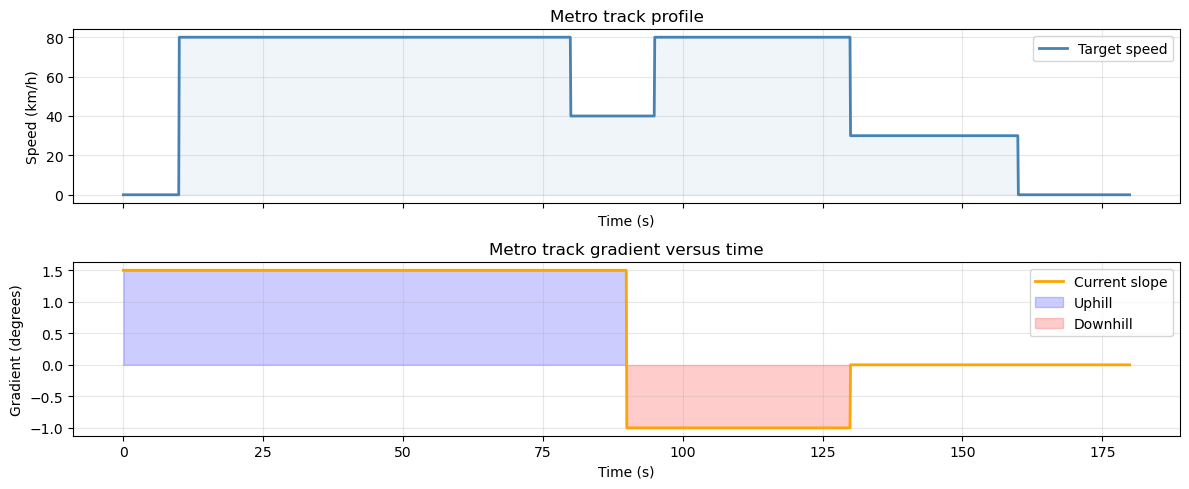

Track profile saved.


In [8]:
TOTAL_TIME = 180
#an array of time stamps divided into .1 lengths.
times = np.arange(0,TOTAL_TIME,DT)

def get_target_speed(t):

    """
    Speed profile for a metro inter-station run.
    Returns target speed in km/h at time t (seconds).

    Station A ──► accelerate ──► cruise ──► slow zone ──► cruise ──► brake ──► Station B
    """

    if   t <  10:  return  0    # standing at Station A
    elif t <  40:  return 80    # accelerate to 80 km/h line speed
    elif t <  80:  return 80    # cruise at 80 km/h
    elif t <  95:  return 40    # speed restriction zone (40 km/h)
    elif t < 130:  return 80    # resume line speed
    elif t < 160:  return 30    # braking approach to Station B
    else:          return  0    # stopped at Station B

def get_gradient(t):

    if 0 <= t < 90:

        return 1.5

    elif 90 <= t < 130:

        return -1.0

    return 0

target_speeds = [get_target_speed(t) for t in times]
gradients = [get_gradient(t) for t in times]

fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,5), sharex=True)

ax1.plot(times, target_speeds, color="steelblue", linewidth=2, label="Target speed")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Speed (km/h)")
ax1.set_title("Metro track profile")
ax1.legend()
ax1.grid(True,alpha=0.3)
ax1.fill_between(times, target_speeds, alpha=0.08, color="steelblue")

ax2.plot(times, gradients, color="orange", linewidth=2, label="Current slope")
ax2.fill_between(times, gradients, 0, where=[g > 0 for g in gradients], 
                 alpha=0.2,color="blue",label="Uphill")
ax2.fill_between(times, gradients, 0, where=[g < 0 for g in gradients], 
                 alpha=0.2, color='red', label= 'Downhill')
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Gradient (degrees)")
ax2.set_title("Metro track gradient versus time")
ax2.legend()
ax2.grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig('week2_track_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print('Track profile saved.')

In [9]:
MASS = 4e4
MAX_TRACTION = 15e4
MAX_BRAKE = 12e4
ROLLING_RES = 2e-3
DT = 0.1
def run_simulation(kp,ki,kd,label="Simulation"):

    pid = PID_Controller(KP=kp,KI=ki,KD=kd)
    pid.reset()

    velocity = 0.0
    position = 0.0

    log = {
        'time' : [],
        'speed_actual' : [],
        'speed_target' : [],
        'speed_error' : [],
        'throttle' : [],
        'brake' : [],
        'position' : [],
        'gradient' : [],
        'pid_output' : [],
        'label' : label,
        'kp' : kp,
        'ki' : ki,
        'kd' : kd
        }

    for t in times:

        target_speed = get_target_speed(t)
        gradient = get_gradient(t)
        log['time'].append(t)
        log['gradient'].append(gradient)
        log['speed_target'].append(target_speed)

        current_speed = velocity * 3.6
        
        pid_out = pid.compute(target_speed, current_speed, DT)
        throttle, brake = convert_to_brake_or_throttle(pid_out)
        

        a = train_acceleration(velocity, throttle, brake, gradient)
        velocity = max(0.0, velocity + a*DT)
        position += velocity * DT

        log['speed_error'].append(target_speed - current_speed)
        log['speed_actual'].append(current_speed)
        log['throttle'].append(throttle)
        log['brake'].append(brake)
        log['position'].append(position)
        log['pid_output'].append(pid_out)

    for key in log:

        if isinstance(log[key], list) and key !='label':

            log[key] = np.array(log[key])

    return log

result = run_simulation(kp=0.8, ki=0.05, kd=1.5, label='Tuned PID')

print(f'Simulation complete.')
#final value of the position: total distance
print(f'Total distance: {result["position"][-1]:.0f} m')
print(f'Max speed error: {np.abs(result["speed_error"]).max():.1f} km/h')
print(f'Mean speed error (cruise only): '
      f'{np.abs(result["speed_error"][400:800]).mean():.2f} km/h')        

Simulation complete.
Total distance: 2933 m
Max speed error: 80.0 km/h
Mean speed error (cruise only): 4.54 km/h


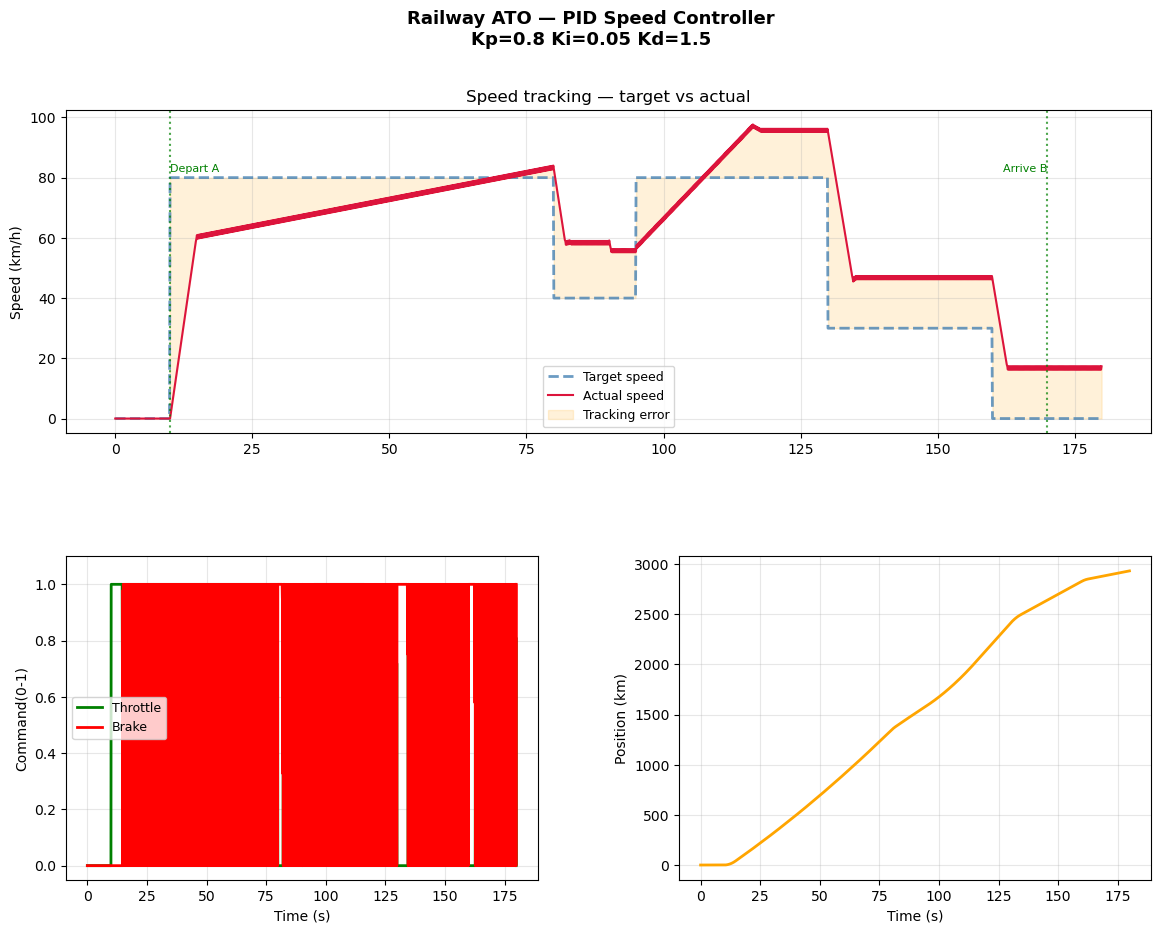

Simulation plot saved.


In [10]:
def plot_simulation(log, title='ATO Simulation'):

    fig = plt.figure(figsize=(14,10))
    fig.suptitle(
        f"{title}\nKp={log['kp']} Ki={log['ki']} Kd={log['kd']}", fontsize=13, fontweight="bold")

    gs = gridspec.GridSpec(2,2, figure=fig, hspace=0.38, wspace=0.3)

    #first row, spans all the columns
    ax1 = fig.add_subplot(gs[0,:])
    
    #plotting the actual and target speed lines
    ax1.plot(log['time'],log['speed_target'], color='steelblue', linewidth=2, linestyle='--',
             label="Target speed", alpha=0.8)
    ax1.plot(log['time'], log['speed_actual'], color='crimson',
             linewidth=1.5, label="Actual speed")

    #filling the difference with a color, ki error (?)
    ax1.fill_between(log['time'],log['speed_actual'],log['speed_target'],alpha=0.15,color='orange'
                     ,label='Tracking error')
    
    ax1.set_ylabel('Speed (km/h)', fontsize=10)
    ax1.set_title('Speed tracking — target vs actual')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)

    #the time it departs from A and the time it arrives at B 
    #(theoretically it should end with 0km/h)
    ax1.axvline(10,color='green',linestyle=':', alpha=0.7)
    ax1.axvline(170,color='green', linestyle=':', alpha=0.7)
    
    #label the vertical lines
    ax1.text(10,  82, 'Depart A', fontsize=8, color='green')
    ax1.text(162, 82, 'Arrive B', fontsize=8, color='green')

    
    ax2 = fig.add_subplot(gs[1,0])
    ax2.plot(log['time'], log['throttle'], color='green', linewidth=2,label="Throttle")
    ax2.plot(log['time'], log['brake'], color='red', linewidth=2, label='Brake')
    ax2.set_xlabel("Time (s)")
    ax2.set_ylabel("Command(0-1)")
    ax2.set_ylim(-0.05,1.1)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

    ax3 = fig.add_subplot(gs[1,1])
    ax3.plot(log['time'], log['position'], color='orange', linewidth=2, label='Position')
    ax3.set_xlabel('Time (s)', fontsize=10)
    ax3.set_ylabel('Position (km)', fontsize=10)
    ax3.grid(True, alpha=0.3)

    plt.savefig('week2_simulation.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Simulation plot saved.')

plot_simulation(result, title='Railway ATO — PID Speed Controller')


#indicate the points on 3rd graph where it starts to use the brakes maybe.
    

## Testting different values of PID constants

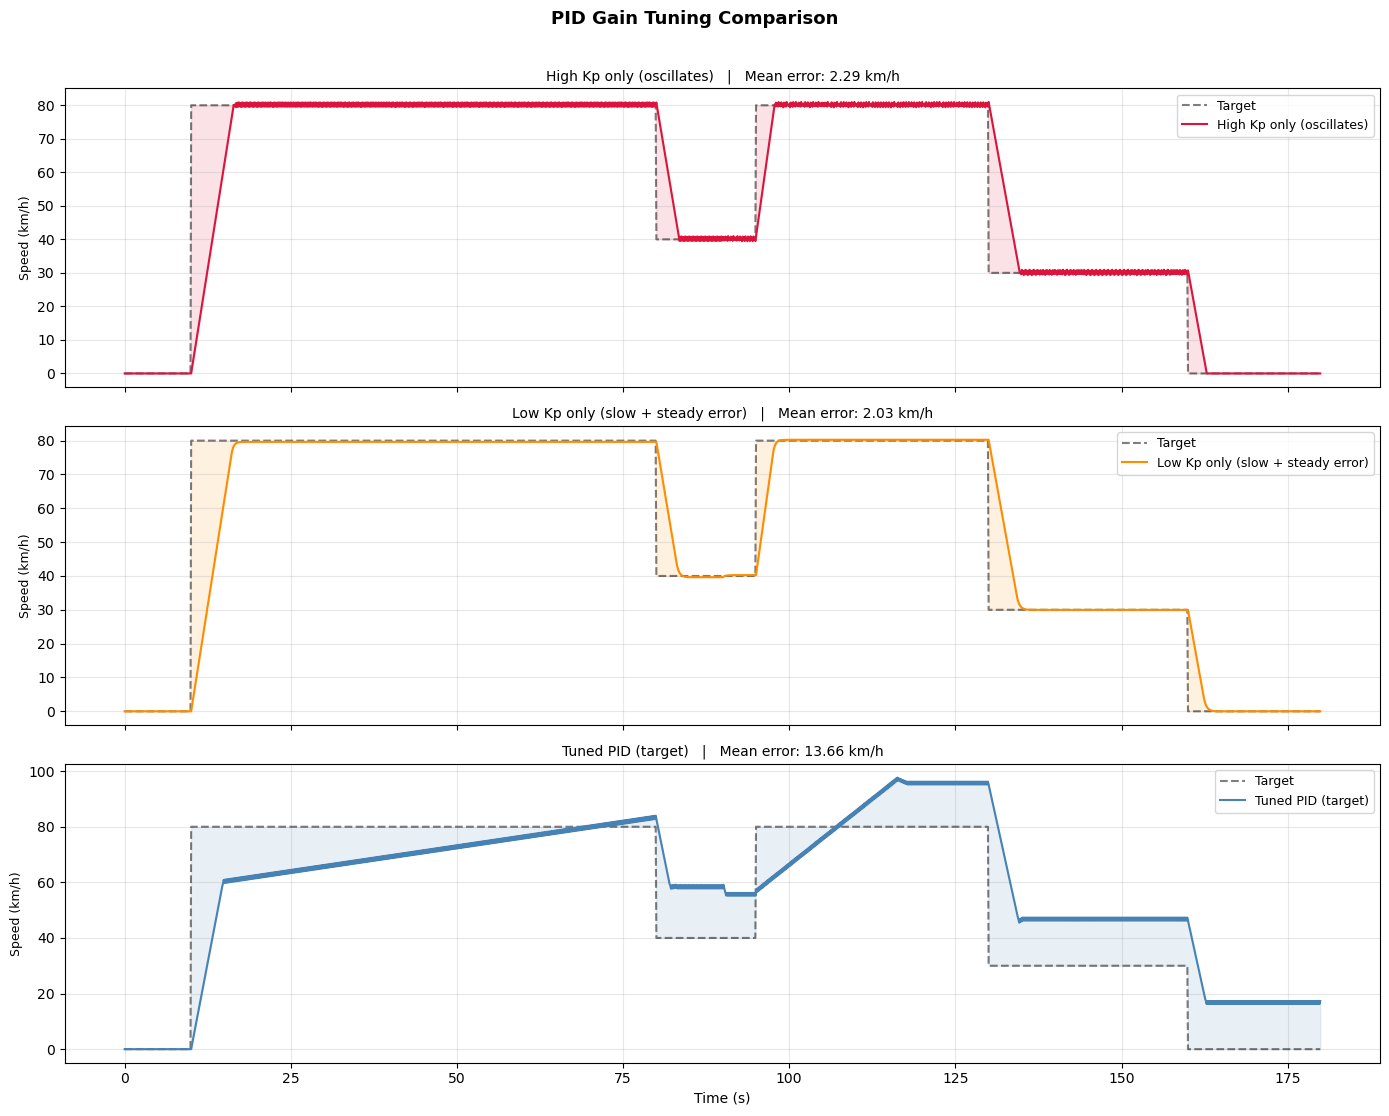

Tuning comparison saved.

High Kp only (oscillates)                 MAE: 2.29 km/h
Low Kp only (slow + steady error)         MAE: 2.03 km/h
Tuned PID (target)                        MAE: 13.66 km/h


In [11]:
configs = [
    dict(kp=2.5,  ki=0.0,  kd=0.0,  label='High Kp only (oscillates)'),
    dict(kp=0.2,  ki=0.0,  kd=0.0,  label='Low Kp only (slow + steady error)'),
    dict(kp=0.8,  ki=0.05, kd=1.5,  label='Tuned PID (target)'),
]

#treat each key-value as a parameter
results = [run_simulation(**cfg) for cfg in configs]

# Plot comparison
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
colors = ['crimson', 'darkorange', 'steelblue']

for ax, res, color in zip(axes, results, colors):
    ax.plot(res['time'], res['speed_target'], 'k--',
            linewidth=1.5, alpha=0.5, label='Target')
    ax.plot(res['time'], res['speed_actual'], color=color,
            linewidth=1.5, label=res['label'])
    ax.fill_between(res['time'],
                    res['speed_target'],
                    res['speed_actual'],
                    alpha=0.12, color=color)
    ax.set_ylabel('Speed (km/h)', fontsize=9)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3)
    mae = np.abs(res['speed_error'][200:]).mean()
    ax.set_title(f"{res['label']}   |   Mean error: {mae:.2f} km/h", fontsize=10)

axes[-1].set_xlabel('Time (s)', fontsize=10)
fig.suptitle('PID Gain Tuning Comparison', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('week2_tuning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('Tuning comparison saved.')
print()
for res in results:
    mae = np.abs(res['speed_error'][200:]).mean()
    print(f"{res['label']:<40}  MAE: {mae:.2f} km/h")

## Finding the Phase and Magnitude margins with a Bode Plot

Frequency-domain analysis tells you why and how robust the stability is: how will the system react when there is a slight change in mass, or it gains drift? The Bode plot aims to answer those questions.

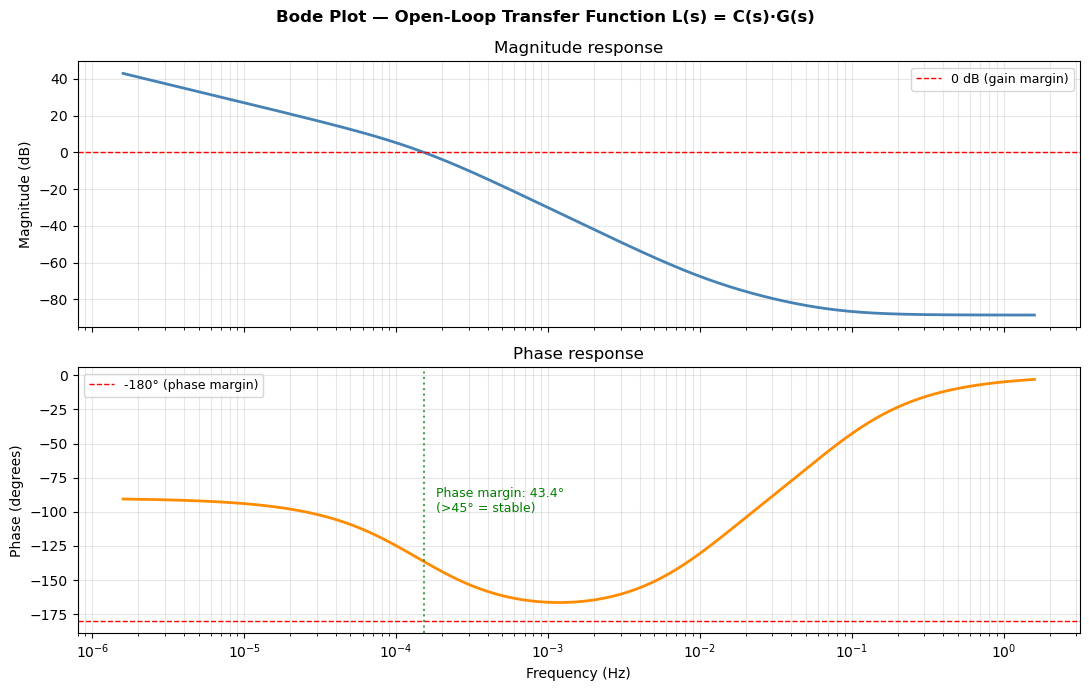

Gain crossover frequency: 0.0002 Hz
Phase margin:             43.4°
Stability assessment:     MARGINALLY STABLE


In [12]:
# ── Transfer function of the train (simplified linearized model) ─────────────
M = MASS          # 40,000 kg
B = ROLLING_RES * MASS * 9.81 / (80/3.6)  # damping at cruise speed

# Plant: G(s) = 1 / (M*s + B)
plant = sp_signal.TransferFunction([1], [M, B])

# PID in transfer function form: C(s) = Kp + Ki/s + Kd*s
# = (Kd*s² + Kp*s + Ki) / s
Kp, Ki, Kd = 0.8, 0.05, 1.5
pid_num = [Kd, Kp, Ki]
pid_den = [1,0]
controller = sp_signal.TransferFunction(pid_num, pid_den)

# Open-loop: L(s) = C(s) × G(s)
open_loop_num = np.polymul(pid_num, plant.num)
open_loop_den = np.polymul(pid_den, plant.den)
open_loop = sp_signal.TransferFunction(open_loop_num, open_loop_den)

# Bode plot
w, mag, phase = sp_signal.bode(open_loop, n=500)
freq_hz = w / (2 * np.pi)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
fig.suptitle('Bode Plot — Open-Loop Transfer Function L(s) = C(s)·G(s)',
             fontsize=12, fontweight='bold')

# Magnitude
ax1.semilogx(freq_hz, mag, color='steelblue', linewidth=2)
ax1.axhline(0, color='red', linestyle='--', linewidth=1, label='0 dB (gain margin)')
ax1.set_ylabel('Magnitude (dB)', fontsize=10)
ax1.set_title('Magnitude response')
ax1.grid(True, which='both', alpha=0.3)
ax1.legend(fontsize=9)

# Phase
ax2.semilogx(freq_hz, phase, color='darkorange', linewidth=2)
ax2.axhline(-180, color='red', linestyle='--', linewidth=1, label='-180° (phase margin)')
ax2.set_ylabel('Phase (degrees)', fontsize=10)
ax2.set_xlabel('Frequency (Hz)', fontsize=10)
ax2.set_title('Phase response')
ax2.grid(True, which='both', alpha=0.3)
ax2.legend(fontsize=9)

# Gain crossover frequency annotation
gc_idx  = np.argmin(np.abs(mag))
gc_freq = freq_hz[gc_idx]
pm      = phase[gc_idx] + 180
ax2.axvline(gc_freq, color='green', linestyle=':', alpha=0.7)
ax2.text(gc_freq * 1.2, -100,
         f'Phase margin: {pm:.1f}°\n(>45° = stable)',
         fontsize=9, color='green')

plt.tight_layout()
plt.savefig('week2_bode_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Gain crossover frequency: {gc_freq:.4f} Hz')
print(f'Phase margin:             {pm:.1f}°')
print(f'Stability assessment:     {"STABLE" if pm > 45 else "MARGINALLY STABLE" if pm > 0 else "UNSTABLE"}')

## Step Response Graph

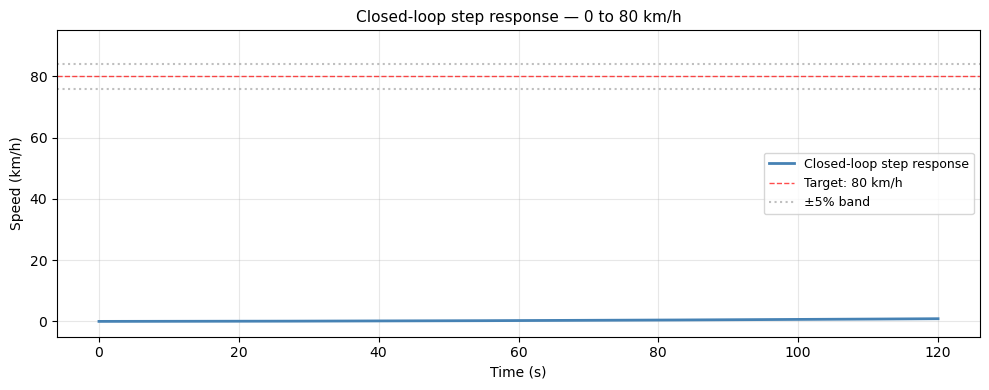

Peak overshoot:  0.00 km/h  (0.0%)


In [13]:
# Closed-loop transfer function: T(s) = L(s) / (1 + L(s))
cl_num = open_loop_num
cl_den = np.polyadd(
    np.pad(open_loop_num, (len(open_loop_den) - len(open_loop_num), 0)),
    open_loop_den
)
closed_loop = sp_signal.TransferFunction(cl_num, cl_den)

t_step = np.linspace(0, 120, 1000)
_, y   = sp_signal.step(closed_loop, T=t_step)

# Get the DC gain (value of T(s) as s→0): T(0) = num(0) / den(0)
dc_gain = np.polyval(closed_loop.num, 0) / np.polyval(closed_loop.den, 0)

# Normalize the output properly
y_kmh = (y / dc_gain) * 80

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_step, y_kmh, color='steelblue', linewidth=2, label='Closed-loop step response')
ax.axhline(80, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Target: 80 km/h')
ax.axhline(80 * 0.95, color='gray', linestyle=':', alpha=0.5)
ax.axhline(80 * 1.05, color='gray', linestyle=':', alpha=0.5, label='±5% band')

# Find settling time (within 5%)
settled = np.where(np.abs(y_kmh - 80) < 4)[0]
if len(settled) > 0:
    t_settle = t_step[settled[0]]
    ax.axvline(t_settle, color='green', linestyle='--', alpha=0.7)
    ax.text(t_settle + 1, 10, f'Settling time\n{t_settle:.1f}s', fontsize=9, color='green')

ax.set_xlabel('Time (s)', fontsize=10)
ax.set_ylabel('Speed (km/h)', fontsize=10)
ax.set_title('Closed-loop step response — 0 to 80 km/h', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-5, 95)
plt.tight_layout()
plt.savefig('week2_step_response.png', dpi=150, bbox_inches='tight')
plt.show()

overshoot = max(0, y_kmh.max() - 80)
print(f'Peak overshoot:  {overshoot:.2f} km/h  ({overshoot/80*100:.1f}%)')
if len(settled) > 0:
    print(f'Settling time:   {t_settle:.1f} s')

## Energy Graphs

Computing the traction energy consumed per time unit (kWh)

In [14]:
import pandas as pd

In [15]:
# ── Energy system parameters ─────────────────────────────────────────────────
TRACTION_EFFICIENCY  = 0.90   # 90% — inverter + motor efficiency during traction,(actual/expected)
REGEN_EFFICIENCY     = 0.75   # 75% — efficiency of energy recovery during braking
                               # (lower because: motor→generator→inverter→grid losses)
REGEN_MAX_TRACTION   = 0.80   # 80% of braking force can be regenerative
                               # remainder is mechanical (friction) braking

def compute_energy(velocity_ms, throttle, brake):

    v = abs(velocity_ms)
    
    f_traction = throttle * MAX_TRACTION
    
    # needs to draw more power from the grid due to the energy losses during the process
    p_traction = f_traction * v / TRACTION_EFFICIENCY if throttle > 0 else 0.0

    f_brake_total = brake * MAX_BRAKE
    f_regen = f_brake_total * REGEN_MAX_TRACTION
    f_friction = f_brake_total * (1-REGEN_MAX_TRACTION)

    # recovers less than mechanical braking power due to ME → EE conversion losses
    p_regen = f_regen * v * REGEN_EFFICIENCY if brake > 0 else 0.0
    p_friction = f_friction * v

    return p_traction, p_regen, p_friction

print('Energy model ready.')
print(f'Traction efficiency:  {TRACTION_EFFICIENCY*100:.0f}%')
print(f'Regen efficiency:     {REGEN_EFFICIENCY*100:.0f}%')

#the 80% of the power created by the braking force goes to the grid, the rest is friction/heat
print(f'Max regen fraction:   {REGEN_MAX_TRACTION*100:.0f}% of braking force')

Energy model ready.
Traction efficiency:  90%
Regen efficiency:     75%
Max regen fraction:   80% of braking force


## Simulation and Energy Analysis

In [16]:
def run_sim_with_energy(kp,ki,kd,label="Simulation"):

    pid = PID_Controller(KP=kp,KI=ki,KD=kd)
    pid.reset()

    velocity = 0
    position = 0.0

    #
    e_traction = 0
    e_regen = 0
    e_friction = 0

    rows = list()

    for t in times:

        target_kmh = get_target_speed(t)
        grad = get_gradient(t)
        current_kmh = velocity * 3.6
        

        pid_out = pid.compute(target_kmh, current_kmh, DT)
        throttle, brake = convert_to_brake_or_throttle(pid_out)

        a = train_acceleration(velocity, throttle, brake, grad)
        velocity = max(0.0, velocity + a * DT)
        position += velocity * DT

        p_trac, p_regen, p_fric = compute_energy(velocity, throttle, brake)

        e_traction += p_trac * DT
        e_regen += p_regen * DT
        e_friction += p_fric * DT

        rows.append({

            'time':t,
            'current_speed':current_kmh,
            'target_speed':target_kmh,
            'gradient (in degrees)': grad,
            'throttle':throttle,
            'brake':brake,
            'position':position,
            
            #kW
            'power_traction':p_trac/1000,
            'power_regen':p_regen/1000,
            'power_friction':p_fric/1000,
            
            #kWh
            'energy_traction':e_traction/3.6e6,
            'energy_regen':e_regen/3.6e6,
            'energy_friction':e_friction/3.6e6,
            'energy_net':(e_traction - e_regen) / 3.6e6
    
 
        })

    df = pd.DataFrame(rows)

    # Summary metrics, convert joules to Watt = J/s, kW = kJ/s, kWh = kJ/h
    e_trac_kwh  = e_traction / 3_600_000
    e_regen_kwh = e_regen    / 3_600_000
    e_net_kwh   = e_trac_kwh - e_regen_kwh
    efficiency  = (e_regen_kwh / e_trac_kwh * 100) if e_trac_kwh > 0 else 0

    summary = {
        'label':        label,
        'kp': kp, 'ki': ki, 'kd': kd,
        'e_traction':   e_trac_kwh,
        'e_regen':      e_regen_kwh,
        'e_net':        e_net_kwh,
        'efficiency':   efficiency,
        'distance_km':  position / 1000,
        'e_per_km':     e_net_kwh / (position / 1000) if position > 0 else 0,
    }

    return df, summary


# Run the tuned simulation
df, summary = run_sim_with_energy(kp=0.8, ki=0.05, kd=1.5, label='Tuned PID')

print('=== Energy Summary ===')
print(f"Traction energy consumed: {summary['e_traction']:.4f} kWh")
print(f"Regenerative energy recovered: {summary['e_regen']:.4f} kWh")
print(f"Net energy:               {summary['e_net']:.4f} kWh")
print(f"Regeneration efficiency:  {summary['efficiency']:.1f}%")
print(f"Distance covered:         {summary['distance_km']:.2f} km")
print(f"Net energy per km:        {summary['e_per_km']:.4f} kWh/km")
        

=== Energy Summary ===
Traction energy consumed: 60.7749 kWh
Regenerative energy recovered: 30.2177 kWh
Net energy:               30.5571 kWh
Regeneration efficiency:  49.7%
Distance covered:         2.93 km
Net energy per km:        10.4190 kWh/km


## Graphing the Energy Analysis Simulation

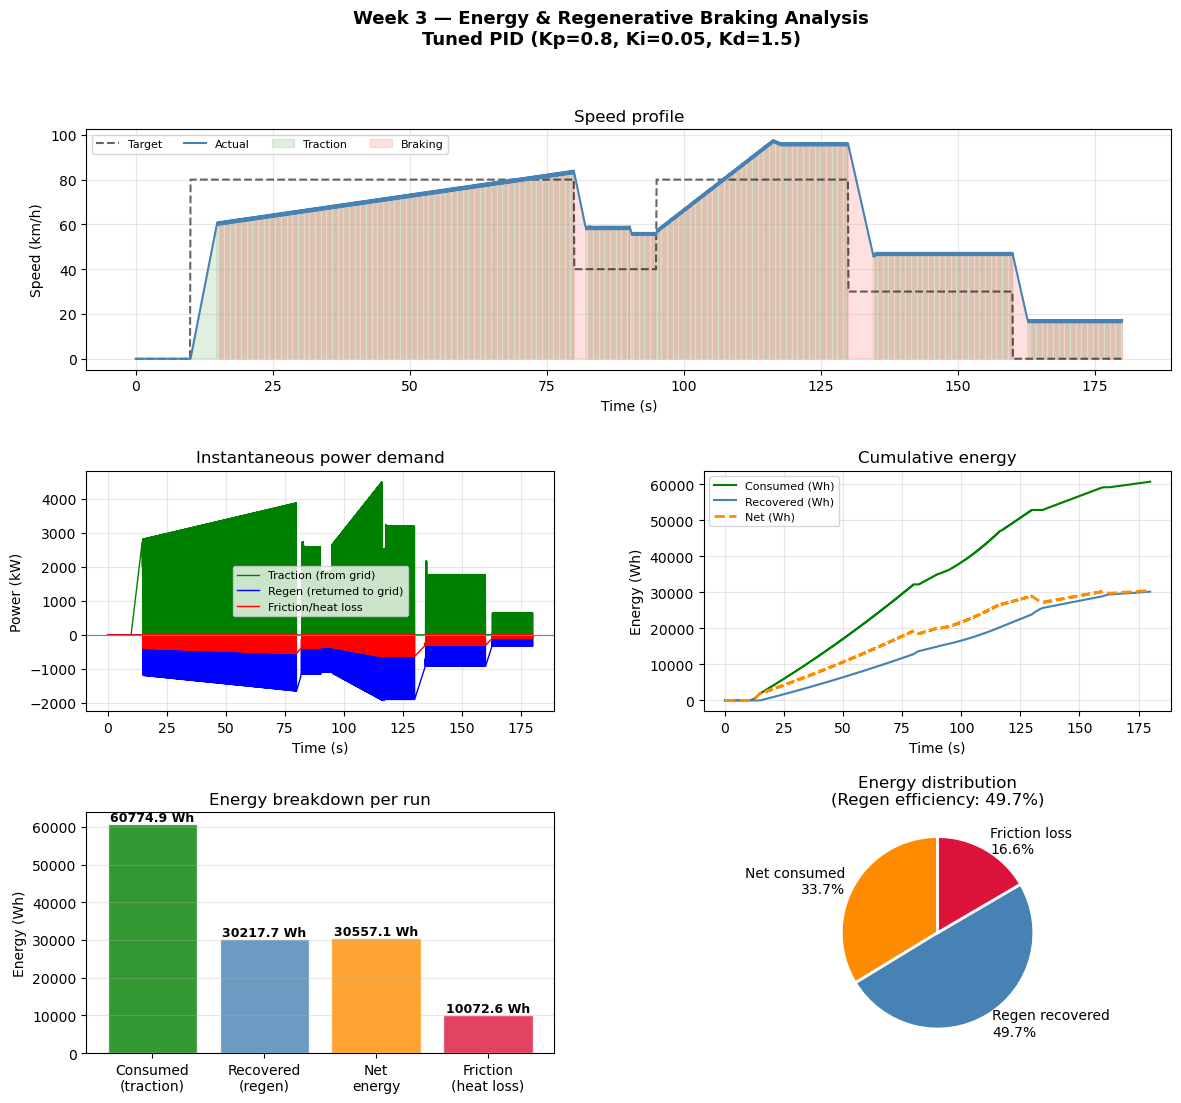

Energy analysis plot saved.


In [17]:
fig = plt.figure(figsize=(14,12))

fig.suptitle('Week 3 — Energy & Regenerative Braking Analysis\nTuned PID (Kp=0.8, Ki=0.05, Kd=1.5)',
             fontsize=13, fontweight='bold')

gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.42, wspace=0.32)

#general current-target speed profile
ax1 = fig.add_subplot(gs[0,:])
ax1.plot(df['time'], df['target_speed'], 'k--', linewidth=1.5, alpha=0.6, label='Target')
ax1.plot(df['time'], df['current_speed'], color='steelblue', linewidth=1.5, label='Actual')
ax1.set_ylabel("Speed (km/h)")
ax1.set_xlabel('Time (s)')
ax1.set_title("Speed profile")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Shade traction vs braking regions

#shade when it applies throttle
ax1.fill_between(df['time'], 0, df['current_speed'],
                 where=df['throttle'] > 0.01,
                 alpha=0.12, color='green', label='Traction')

# shade when it applies a brake
ax1.fill_between(df['time'], 0, df['current_speed'],
                 where=df['brake'] > 0.01,
                 alpha=0.12, color='red', label='Braking')
ax1.legend(fontsize=8, ncol=4)

ax2 = fig.add_subplot(gs[1,0])
ax2.plot(df['time'], df['power_traction'], color='green', linewidth=1.0, label="Traction (from grid)")
ax2.plot(df['time'], -df['power_regen'], color='blue', linewidth=1.0, label='Regen (returned to grid)')
ax2.plot(df['time'], -df['power_friction'], color='red', linewidth=1.0, label='Friction/heat loss')

#Instantaneous power generated
ax2.axhline(0,color='gray',linewidth=0.8)
ax2.set_ylabel('Power (kW)')
ax2.set_xlabel('Time (s)')
ax2.set_title('Instantaneous power demand')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(df['time'], df['energy_traction'] * 1000, color='green',
         linewidth=1.5, label='Consumed (Wh)')
ax3.plot(df['time'], df['energy_regen'] * 1000, color='steelblue',
         linewidth=1.5, label='Recovered (Wh)')
ax3.plot(df['time'], df['energy_net'] * 1000, color='darkorange',
         linewidth=2.0, linestyle='--', label='Net (Wh)')
ax3.set_ylabel('Energy (Wh)')
ax3.set_xlabel('Time (s)')
ax3.set_title('Cumulative energy')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)




# Energy breakdown
ax4 = fig.add_subplot(gs[2, 0])
categories = ['Consumed\n(traction)', 'Recovered\n(regen)', 'Net\nenergy', 'Friction\n(heat loss)']
values_wh  = [
    summary['e_traction'] * 1000,
    summary['e_regen']    * 1000,
    summary['e_net']      * 1000,
    df['energy_friction'].iloc[-1] * 1000,
]
colors_bar = ['green', 'steelblue', 'darkorange', 'crimson']
bars = ax4.bar(categories, values_wh, color=colors_bar, alpha=0.8, edgecolor='white')
for bar, val in zip(bars, values_wh):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.1f} Wh', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax4.set_ylabel('Energy (Wh)')
ax4.set_title('Energy breakdown per run')
ax4.grid(True, alpha=0.3, axis='y')

ax5 = fig.add_subplot(gs[2, 1])

#regen/traction
regen_pct    = summary['efficiency']

# how many percent of the traction energy converted to friction (friction+regen=traction)
friction_pct = df['energy_friction'].iloc[-1] / summary['e_traction'] * 100
net_pct      = 100 - regen_pct - friction_pct

sizes  = [max(0, net_pct), max(0, regen_pct), max(0, friction_pct)]
labels = [f'Net consumed\n{net_pct:.1f}%',
          f'Regen recovered\n{regen_pct:.1f}%',
          f'Friction loss\n{friction_pct:.1f}%']


colors_pie = ['darkorange', 'steelblue', 'crimson']
ax5.pie(sizes, labels=labels, colors=colors_pie,
        autopct='', startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax5.set_title(f'Energy distribution\n(Regen efficiency: {regen_pct:.1f}%)')

plt.savefig('week3_energy_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Energy analysis plot saved.')


## Energy Comparison with Different Tunings

In [18]:
configs = [
    dict(kp=2.5,  ki=0.0,  kd=0.0,  label='High Kp only (oscillates)'),
    dict(kp=0.2,  ki=0.0,  kd=0.0,  label='Low Kp only'),
    dict(kp=0.8,  ki=0.05, kd=1.5,  label='Tuned PID (target)'),
]

all_results = list()


for cfg in configs:

    df_run, summ = run_sim_with_energy(**cfg)
    all_results.append((df_run, summ))

# Comparison table

print(f"{'Label':<25} {'Consumed (Wh)':>14} {'Recovered (Wh)':>15} {'Net (Wh)':>10} {'Regen %':>8} {'Wh/km':>8}")
print('-' * 85)

#only look at the summs
for _, summ in all_results:
    print(f"{summ['label']:<25} "
          f"{summ['e_traction']*1000:>14.1f} "
          f"{summ['e_regen']*1000:>15.1f} "
          f"{summ['e_net']*1000:>10.1f} "
          f"{summ['efficiency']:>7.1f}% "
          f"{summ['e_per_km']*1000:>8.2f}")

Label                      Consumed (Wh)  Recovered (Wh)   Net (Wh)  Regen %    Wh/km
-------------------------------------------------------------------------------------
High Kp only (oscillates)        54219.7         26586.1    27633.6    49.0% 10103.25
Low Kp only                      10565.5          3462.8     7102.7    32.8%  2610.28
Tuned PID (target)               60774.9         30217.7    30557.1    49.7% 10418.99


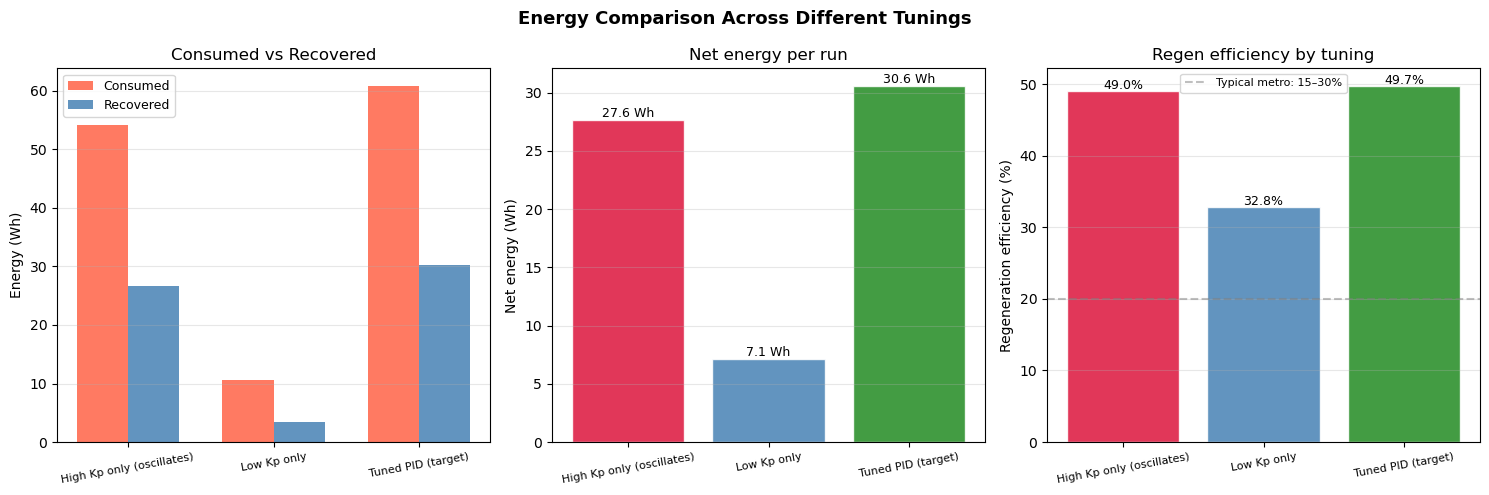

Tuning energy comparison saved.


In [19]:
fig, axes = plt.subplots(1,3,figsize=(15,5))
fig.suptitle('Energy Comparison Across Different Tunings', fontsize=13, fontweight='bold')

labels = [s['label'] for _, s in all_results]
consumed = [s['e_traction'] for _, s in all_results]
recovered = [s['e_regen'] for _, s in all_results]
net = [s['e_net'] for _, s in all_results]
regen_pct = [s['efficiency'] for _, s in all_results]


x = np.arange(len(labels))
width = 0.35
bar_colors = ['crimson', 'steelblue', 'forestgreen']

#left--> consumed
axes[0].bar(x-width/2, consumed, width, label='Consumed', color='tomato', alpha=0.85)
#right--> recovered
axes[0].bar(x+width/2, recovered, width, label='Recovered', color='steelblue', alpha=0.85)

#outline of the x-axis display
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, fontsize=8, rotation=10)
axes[0].set_ylabel('Energy (Wh)')
axes[0].set_title('Consumed vs Recovered')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(labels, net, color=bar_colors, alpha=0.85, edgecolor='white')
for i, (bar_x, val) in enumerate(zip(x, net)):

    axes[1].text(bar_x, val + 0.3, f'{val:.1f} Wh', ha='center', fontsize=9)

axes[1].set_ylabel('Net energy (Wh)')
axes[1].set_title('Net energy per run')
axes[1].set_xticks(x); axes[1].set_xticklabels(labels, fontsize=8, rotation=10)
axes[1].grid(True, alpha=0.3, axis='y')

# Regen efficiency
bars = axes[2].bar(labels, regen_pct, color=bar_colors, alpha=0.85, edgecolor='white')
axes[2].axhline(20, color='gray', linestyle='--', alpha=0.5, label='Typical metro: 15–30%')
for bar_x, val in zip(x, regen_pct):
    #write a text above the bars
    axes[2].text(bar_x, val + 0.3, f'{val:.1f}%', ha='center', fontsize=9)
axes[2].set_ylabel('Regeneration efficiency (%)')
axes[2].set_title('Regen efficiency by tuning')
axes[2].set_xticks(x); axes[2].set_xticklabels(labels, fontsize=8, rotation=10)
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('week3_tuning_energy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Tuning energy comparison saved.')


Standard profile net energy:  30557.13 Wh
Coasting profile net energy:  30171.16 Wh
Energy saved by coasting:     385.98 Wh  (1.3%)


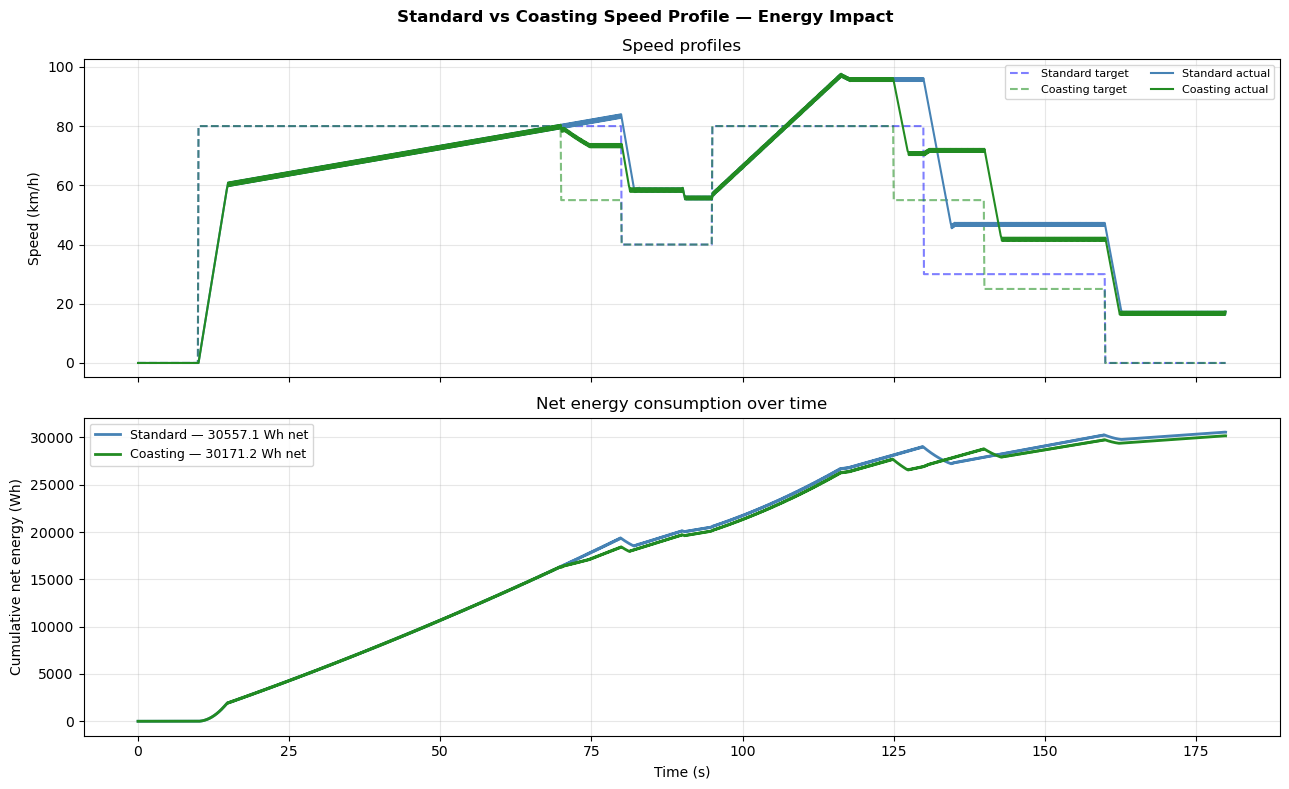

In [20]:
#like stop pressing the accelerator and let it slow down by itself without using the brake -> saved energy

def get_target_speed_coasting(t):
    """
    Energy-optimized speed profile with earlier speed reductions
    (coasting before speed restrictions and stations).
    """
    if   t <  10: return  0
    elif t <  40: return 80
    elif t <  70: return 80    # start reducing earlier before speed zone
    elif t <  80: return 55    # gentle ramp down instead of sharp drop
    elif t <  95: return 40
    elif t < 125: return 80
    elif t < 140: return 55    # coast earlier before station
    elif t < 160: return 25
    else:         return  0


import types

def run_with_custom_profile(speed_fn, kp=0.8, ki=0.05, kd=1.5, label='Custom'):

    pid = PID_Controller(kp,ki,kd)
    pid.reset()
    
    velocity = 0.0
    position = 0.0

    e_trac = 0.0; e_regen = 0.0; e_friction = 0.0
    rows = list()

    for t in times:

        target_kmh = speed_fn(t)
        grad = get_gradient(t)
        current = velocity * 3.6
        pid_out = pid.compute(target_kmh, current, DT)
        throttle, brake = convert_to_brake_or_throttle(pid_out)
        
        a = train_acceleration(velocity, throttle, brake, grad)
        velocity = max(0, velocity + a * DT)
        position += velocity * DT
        
        pt, pr, pf = compute_energy(velocity, throttle, brake)
        e_trac += pt * DT; e_regen += pr * DT; e_friction += pf * DT

        rows.append({'time': t, 'speed_actual': current,
                     'speed_target': target_kmh,
                     'energy_traction': e_trac/3.6e6,
                     'energy_regen': e_regen/3.6e6,
                     'energy_net': (e_trac-e_regen)/3.6e6})

        df = pd.DataFrame(rows)
        summ = {
        'label': label,
        'e_traction': e_trac/3.6e6,
        'e_regen':    e_regen/3.6e6,
        'e_net':      (e_trac-e_regen)/3.6e6,
        'efficiency': e_regen/e_trac*100 if e_trac > 0 else 0,
        'distance_km': position/1000,
    }
    return df, summ

df_std, s_std = run_with_custom_profile(get_target_speed, label='Standard Profile')
df_coast, s_coast = run_with_custom_profile(get_target_speed_coasting, label="Coasting Profile")

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
fig.suptitle('Standard vs Coasting Speed Profile — Energy Impact',
             fontsize=12, fontweight='bold')

axes[0].plot(df_std['time'],   df_std['speed_target'],   'b--', alpha=0.5, label='Standard target')
axes[0].plot(df_coast['time'], df_coast['speed_target'],  'g--', alpha=0.5, label='Coasting target')
axes[0].plot(df_std['time'],   df_std['speed_actual'],   'steelblue', linewidth=1.5, label='Standard actual')
axes[0].plot(df_coast['time'], df_coast['speed_actual'],  'forestgreen', linewidth=1.5, label='Coasting actual')
axes[0].set_ylabel('Speed (km/h)')
axes[0].legend(fontsize=8, ncol=2)
axes[0].grid(True, alpha=0.3)
axes[0].set_title('Speed profiles')

axes[1].plot(df_std['time'],   df_std['energy_net']   * 1000, 'steelblue',   linewidth=2, label=f"Standard — {s_std['e_net']*1000:.1f} Wh net")
axes[1].plot(df_coast['time'], df_coast['energy_net'] * 1000, 'forestgreen', linewidth=2, label=f"Coasting — {s_coast['e_net']*1000:.1f} Wh net")
axes[1].set_ylabel('Cumulative net energy (Wh)')
axes[1].set_xlabel('Time (s)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_title('Net energy consumption over time')

savings = (s_std['e_net'] - s_coast['e_net']) * 1000
savings_pct = savings / (s_std['e_net'] * 1000) * 100
print(f"Standard profile net energy:  {s_std['e_net']*1000:.2f} Wh")
print(f"Coasting profile net energy:  {s_coast['e_net']*1000:.2f} Wh")
print(f"Energy saved by coasting:     {savings:.2f} Wh  ({savings_pct:.1f}%)")

plt.tight_layout()
plt.savefig('week3_coasting_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [21]:
# ── Export to CSV (Streamlit / pandas) ───────────────────────────────────────
df.to_csv('ato_simulation_results.csv', index=False)
print('Saved: ato_simulation_results.csv')

# ── Export to .mat (MATLAB) ───────────────────────────────────────────────────
try:
    import scipy.io as sio
    sio.savemat('ato_simulation_results.mat', {
        't':               df['time'].values,
        'speed_actual':    df['current_speed'].values,
        'speed_target':    df['target_speed'].values,
        'throttle':        df['throttle'].values,
        'brake':           df['brake'].values,
        'power_traction':  df['power_traction'].values,
        'power_regen':     df['power_regen'].values,
        'energy_traction': df['energy_traction'].values,
        'energy_regen':    df['energy_regen'].values,
        'energy_net':      df['energy_net'].values,
        'e_traction_kwh':  np.array([summary['e_traction']]),
        'e_regen_kwh':     np.array([summary['e_regen']]),
        'e_net_kwh':       np.array([summary['e_net']]),
        'regen_efficiency':np.array([summary['efficiency']]),
    })
    print('Saved: ato_simulation_results.mat')
except Exception as e:
    print(f'MAT export skipped: {e}')

print()
print('Files ready for:')
print('  Week 7 Streamlit dashboard  →  ato_simulation_results.csv')
print('  Week 9 MATLAB/Simulink      →  ato_simulation_results.mat')

Saved: ato_simulation_results.csv
Saved: ato_simulation_results.mat

Files ready for:
  Week 7 Streamlit dashboard  →  ato_simulation_results.csv
  Week 9 MATLAB/Simulink      →  ato_simulation_results.mat
